In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
dataset_path = r"C:\Users\DELL\Data-Science-Projects\fresh-harvest-project\FRUIT-16K"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

16000

In [5]:
class_names = dataset.classes
class_names

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [6]:
num_classes = len(dataset.classes)
num_classes

16

In [7]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(12000, 4000)

In [8]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
labels[1]

tensor(11)

In [12]:
images[1].shape

torch.Size([3, 224, 224])

In [13]:
images[1].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


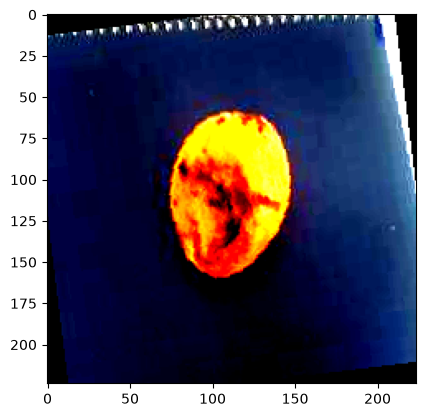

In [14]:
plt.imshow(images[1].permute(1,2,0))
plt.show()

In [15]:
class FruitAndFreshClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [16]:
images.size(0)

32

In [17]:
len(train_loader.dataset)

12000

In [15]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

    return all_labels, all_predictions

In [19]:
# Instantiate the model, loss function, and optimizer
model = FruitAndFreshClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 2.78
Batch: 20, Epoch: 1, Loss: 2.58
Batch: 30, Epoch: 1, Loss: 2.64
Batch: 40, Epoch: 1, Loss: 2.46
Batch: 50, Epoch: 1, Loss: 2.15
Batch: 60, Epoch: 1, Loss: 2.27
Batch: 70, Epoch: 1, Loss: 1.87
Batch: 80, Epoch: 1, Loss: 2.04
Batch: 90, Epoch: 1, Loss: 1.48
Batch: 100, Epoch: 1, Loss: 2.07
Batch: 110, Epoch: 1, Loss: 1.32
Batch: 120, Epoch: 1, Loss: 1.88
Batch: 130, Epoch: 1, Loss: 1.31
Batch: 140, Epoch: 1, Loss: 1.32
Batch: 150, Epoch: 1, Loss: 1.40
Batch: 160, Epoch: 1, Loss: 1.44
Batch: 170, Epoch: 1, Loss: 0.97
Batch: 180, Epoch: 1, Loss: 1.02
Batch: 190, Epoch: 1, Loss: 0.94
Batch: 200, Epoch: 1, Loss: 1.03
Batch: 210, Epoch: 1, Loss: 0.94
Batch: 220, Epoch: 1, Loss: 1.04
Batch: 230, Epoch: 1, Loss: 1.09
Batch: 240, Epoch: 1, Loss: 1.09
Batch: 250, Epoch: 1, Loss: 0.89
Batch: 260, Epoch: 1, Loss: 0.89
Batch: 270, Epoch: 1, Loss: 0.90
Batch: 280, Epoch: 1, Loss: 0.91
Batch: 290, Epoch: 1, Loss: 0.92
Batch: 300, Epoch: 1, Loss: 0.59
Batch: 310, Epoch: 

In [20]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses, val_accuracies = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs.to(device))
            loss = criterion(outputs, labels.to(device))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs.to(device))
                loss = criterion(outputs, labels.to(device))
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.cpu().numpy())
                y_true.extend(labels.cpu().numpy())
        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    return train_losses, val_losses, val_accuracies

Epoch 1/10, Train Loss: 1.2558, Val Loss: 0.7124, Val Accuracy: 0.7408
Epoch 2/10, Train Loss: 0.5580, Val Loss: 0.4559, Val Accuracy: 0.8435
Epoch 3/10, Train Loss: 0.3708, Val Loss: 0.4051, Val Accuracy: 0.8582
Epoch 4/10, Train Loss: 0.2868, Val Loss: 0.3369, Val Accuracy: 0.8855
Epoch 5/10, Train Loss: 0.2262, Val Loss: 0.2679, Val Accuracy: 0.9103
Epoch 6/10, Train Loss: 0.1885, Val Loss: 0.2525, Val Accuracy: 0.9210
Epoch 7/10, Train Loss: 0.1463, Val Loss: 0.3223, Val Accuracy: 0.9040
Epoch 8/10, Train Loss: 0.1460, Val Loss: 0.1750, Val Accuracy: 0.9387
Epoch 9/10, Train Loss: 0.1124, Val Loss: 0.2162, Val Accuracy: 0.9257
Epoch 10/10, Train Loss: 0.0988, Val Loss: 0.1483, Val Accuracy: 0.9547


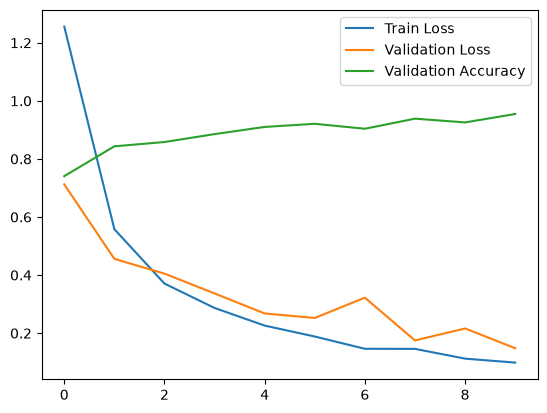

In [21]:
from sklearn.metrics import accuracy_score
model = FruitAndFreshClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses_no_dropout, val_losses_no_dropout, val_accuracies_no_dropout = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=10
)

# Plot training and validation loss and accuracy (Without Dropout)
plt.plot(train_losses_no_dropout, label="Train Loss")
plt.plot(val_losses_no_dropout, label="Validation Loss")
plt.plot(val_accuracies_no_dropout, label="Validation Accuracy")
plt.legend()
plt.show()

In [22]:
class FruitAndFreshClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [23]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

    return all_labels, all_predictions
model = FruitAndFreshClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

all_labels, all_predictions = train_model(model, criterion, optimizer,  epochs=10)

Batch: 10, Epoch: 1, Loss: 16.21
Batch: 20, Epoch: 1, Loss: 3.88
Batch: 30, Epoch: 1, Loss: 2.78
Batch: 40, Epoch: 1, Loss: 2.78
Batch: 50, Epoch: 1, Loss: 2.63
Batch: 60, Epoch: 1, Loss: 2.57
Batch: 70, Epoch: 1, Loss: 2.59
Batch: 80, Epoch: 1, Loss: 2.81
Batch: 90, Epoch: 1, Loss: 2.42
Batch: 100, Epoch: 1, Loss: 2.72
Batch: 110, Epoch: 1, Loss: 2.67
Batch: 120, Epoch: 1, Loss: 2.37
Batch: 130, Epoch: 1, Loss: 2.49
Batch: 140, Epoch: 1, Loss: 2.33
Batch: 150, Epoch: 1, Loss: 2.60
Batch: 160, Epoch: 1, Loss: 2.47
Batch: 170, Epoch: 1, Loss: 2.33
Batch: 180, Epoch: 1, Loss: 2.48
Batch: 190, Epoch: 1, Loss: 2.43
Batch: 200, Epoch: 1, Loss: 2.45
Batch: 210, Epoch: 1, Loss: 2.39
Batch: 220, Epoch: 1, Loss: 2.50
Batch: 230, Epoch: 1, Loss: 2.34
Batch: 240, Epoch: 1, Loss: 2.20
Batch: 250, Epoch: 1, Loss: 2.15
Batch: 260, Epoch: 1, Loss: 2.27
Batch: 270, Epoch: 1, Loss: 2.25
Batch: 280, Epoch: 1, Loss: 2.16
Batch: 290, Epoch: 1, Loss: 2.08
Batch: 300, Epoch: 1, Loss: 2.37
Batch: 310, Epoch:

In [16]:
# Load the pre-trained ResNet model
class FruitAndFreshClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [17]:
model = FruitAndFreshClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=3)

Batch: 10, Epoch: 1, Loss: 1.42
Batch: 20, Epoch: 1, Loss: 0.24
Batch: 30, Epoch: 1, Loss: 0.11
Batch: 40, Epoch: 1, Loss: 0.16
Batch: 50, Epoch: 1, Loss: 0.10
Batch: 60, Epoch: 1, Loss: 0.38
Batch: 70, Epoch: 1, Loss: 0.24
Batch: 80, Epoch: 1, Loss: 0.13
Batch: 90, Epoch: 1, Loss: 0.07
Batch: 100, Epoch: 1, Loss: 0.03
Batch: 110, Epoch: 1, Loss: 0.15
Batch: 120, Epoch: 1, Loss: 0.13
Batch: 130, Epoch: 1, Loss: 0.04
Batch: 140, Epoch: 1, Loss: 0.05
Batch: 150, Epoch: 1, Loss: 0.25
Batch: 160, Epoch: 1, Loss: 0.26
Batch: 170, Epoch: 1, Loss: 0.13
Batch: 180, Epoch: 1, Loss: 0.01
Batch: 190, Epoch: 1, Loss: 0.13
Batch: 200, Epoch: 1, Loss: 0.08
Batch: 210, Epoch: 1, Loss: 0.01
Batch: 220, Epoch: 1, Loss: 0.02
Batch: 230, Epoch: 1, Loss: 0.04
Batch: 240, Epoch: 1, Loss: 0.02
Batch: 250, Epoch: 1, Loss: 0.11
Batch: 260, Epoch: 1, Loss: 0.02
Batch: 270, Epoch: 1, Loss: 0.00
Batch: 280, Epoch: 1, Loss: 0.00
Batch: 290, Epoch: 1, Loss: 0.01
Batch: 300, Epoch: 1, Loss: 0.01
Batch: 310, Epoch: 

In [18]:
torch.save(model.state_dict(), 'saved_model.pth')